In [93]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import os
os.chdir("/Users/AlanHDLR/Desktop")

In [95]:
drugs = pd.read_csv("drugs.csv")
drugs

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [97]:
# Columnas de referencia
feature_cols = ["Age", "Sex", "BP", "Cholesterol", "Na_to_K"]
X = drugs[feature_cols].values
y = drugs.Drug

In [99]:
# Preprocesamiento para las variables categoricas
from sklearn import preprocessing

# Columna Sex
Cod_sex = preprocessing.LabelEncoder()
Cod_sex.fit(["F", "M"])
X[:,1] = Cod_sex.transform(X[:,1])

# Columna BP
Cod_bp = preprocessing.LabelEncoder()
Cod_bp.fit(["HIGH", "NORMAL", "LOW"])
X[:,2] = Cod_bp.transform(X[:,2])

# Columna Cholesterol
Cod_cholesterol = preprocessing.LabelEncoder()
Cod_cholesterol.fit(["HIGH", "NORMAL"])
X[:,3] = Cod_cholesterol.transform(X[:,3])

In [101]:
X[0:5]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

In [103]:
y[0:5]

0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: object

In [105]:
# Creación de grupos de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

# Criterio de "Gini"

In [108]:
# Crear objeto de clasificación del árbol de decisión
clf = DecisionTreeClassifier(criterion = 'gini')

#A plicación del algortimo de árboles de decisión a los grupos de entrenamiento
clf = clf.fit(X_train, y_train)

# Predicción de las respuestas para el grupo de prueba
y_pred = clf.predict(X_test)

In [110]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 4,  0,  0,  0,  0],
       [ 2,  4,  0,  0,  0],
       [ 0,  0,  4,  0,  0],
       [ 0,  0,  0, 19,  0],
       [ 0,  0,  0,  0, 27]], dtype=int64)

In [112]:
# Estadisticas de desempeño
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



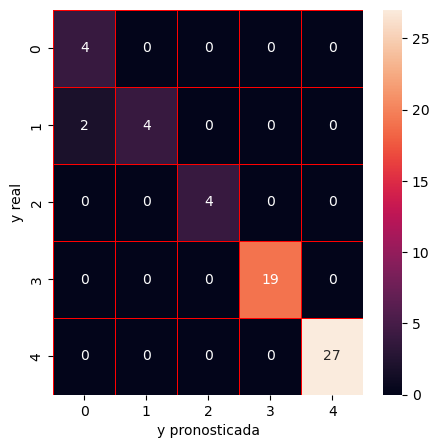

In [114]:
import seaborn as sns
f, ax = plt.subplots(figsize = (5,5))

sns.heatmap(cm, annot = True, linewidths = 0.5, linecolor = "red", fmt = ".0f", ax=ax)
plt.xlabel("y pronosticada")
plt.ylabel("y real")
plt.show()

In [116]:
# Otras librerias necesarias para visualizar los árboles
from sklearn import tree
import graphviz
import pydotplus
from PIL import Image

In [118]:
# Creación de información para el árbol (reglas de decisión)
dot_data = tree.export_graphviz(clf, out_file = None, feature_names = feature_cols, class_names = ["drugA", "drugB", "drugC", "drugX", "drugY", ])

# Creación de la grafica del árbol
graph = pydotplus.graph_from_dot_data(dot_data)

In [32]:
import os
# Cambia la ruta por la carpeta 'bin' donde se instaló Graphviz en tu PC
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'

# Creación del árbol en formato PDF
graph.write_pdf("Drugs.pdf")

# Creación del árbol en formato PNG
graph.write_png("Drugs.png")

image = Image.open("Drugs.png")
image.show()

# Criterio de "entropy"

In [121]:
# Se puede definir una maxima profundidad
# Crear objeto de clasificación del árbol de decisión
clf = DecisionTreeClassifier(criterion = 'entropy', max_depth = 5)

#A plicación del algortimo de árboles de decisión a los grupos de entrenamiento
clf = clf.fit(X_train, y_train)

# Predicción de las respuestas para el grupo de prueba
y_pred = clf.predict(X_test)

In [123]:
# Estadisticas de desempeño
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



In [129]:
# Creación de información para el árbol (reglas de decisión)
dot_data = tree.export_graphviz(clf, out_file = None, feature_names = feature_cols, class_names = ["drugA", "drugB", "drugC", "drugX", "drugY", ])

# Creación de la grafica del árbol
graph = pydotplus.graph_from_dot_data(dot_data)

In [127]:
import os
# Cambia la ruta por la carpeta 'bin' donde se instaló Graphviz en tu PC
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'

# Creación del árbol en formato PDF
graph.write_pdf("Drugs.pdf")

# Creación del árbol en formato PNG
graph.write_png("Drugs.png")

image = Image.open("Drugs.png")
image.show()

# Criterio de "Gini"

In [132]:
# Crear objeto de clasificación del árbol de decisión
clf = DecisionTreeClassifier(criterion = 'gini')

#A plicación del algortimo de árboles de decisión a los grupos de entrenamiento
clf = clf.fit(X_train, y_train)

# Predicción de las respuestas para el grupo de prueba
y_pred = clf.predict(X_test)

In [143]:
# Insertamos al nuevo paciente con los valores categoricos procesados
nuevo_paciente = {
    "Age": 50,
    "Sex": 0,
    "BP": 0,
    "Cholesterol": 1,
    "Na_to_K": 15.302
}

# Convertimos a DataFrame
df_paciente = pd.DataFrame([nuevo_paciente])

# Maquina Vectorial : "rbf"
prediccion = clf.predict(df_paciente)
print("El medicamento recomendado es: " + prediccion)

['El medicamento recomendado es: drugY']


# Criterio de "entropy"

In [137]:
# Crear objeto de clasificación del árbol de decisión
clf = DecisionTreeClassifier(criterion = 'entropy', max_depth = 5)

#A plicación del algortimo de árboles de decisión a los grupos de entrenamiento
clf = clf.fit(X_train, y_train)

# Predicción de las respuestas para el grupo de prueba
y_pred = clf.predict(X_test)

In [141]:
# Insertamos al nuevo paciente con los valores categoricos procesados
nuevo_paciente = {
    "Age": 50,
    "Sex": 0,
    "BP": 0,
    "Cholesterol": 1,
    "Na_to_K": 15.302
}

# Convertimos a DataFrame
df_paciente = pd.DataFrame([nuevo_paciente])

# Maquina Vectorial : "rbf"
prediccion = clf.predict(df_paciente)
print("El medicamento recomendado es: " + prediccion)

['El medicamento recomendado es: drugY']
